#### ADALINE para AND : Widrow-hoff analítico

Matriz de datos originales
[[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]

Vector de etiquetas
[0 0 0 1]

Matriz Z
[[0. 0. 1.]
 [0. 1. 1.]
 [1. 0. 1.]
 [1. 1. 1.]]

Matriz R
[[0.5  0.25 0.5 ]
 [0.25 0.5  0.5 ]
 [0.5  0.5  1.  ]]

Vector h
[0.25 0.25 0.25]

Vector solución óptima X
[ 0.5   0.5  -0.25]

Valores de pesos y bias

Valor de b:-0.25

Valor de w:[0.5 0.5]

Salida de la red a :
[-0.25  0.25  0.25  0.75]

SALIDA CLASIFICADA y_pred
[0 0 0 1]

MSE
0.0625

CONTEO PARA CONFUSION MATRIX
TN = 3
FP = 0
FN = 0
TP = 1

CONFUSION MATRIX
Filas = reales [0,1]
Columnas = predichas [0,1]
[[3 0]
 [0 1]]


MÉTRICAS
Accuracy  = 1.0
Precision = 1.0
Recall    = 1.0


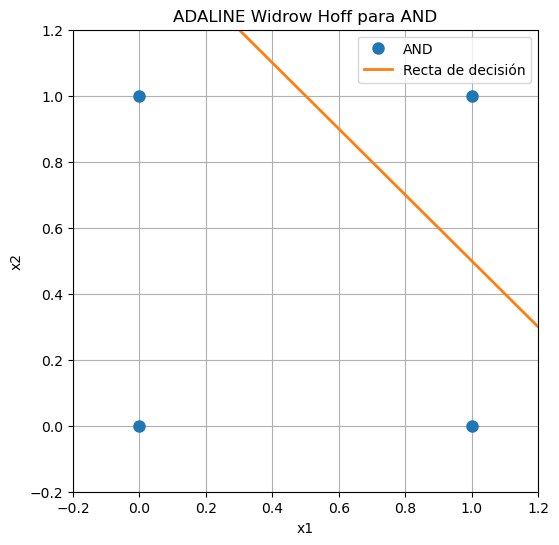

In [21]:
import numpy as np
import matplotlib.pyplot as plt

#Datos de AND
P = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]], dtype=float)

t= np.array([0,0,0,1], dtype=int )
Q= len(P) # Número de patrones

#construcción de Z donde Zq=[p1,p2,1] para cada patrón
Z= np.hstack((P,np.ones((Q, 1))))

#calculo de R y h para cada patrón
#R = (1/Q) * Z^T Z
#h = (1/Q) * Z^T t
R= 1/Q * Z.T @ Z
h= 1/Q * Z.T @ t

#Ahora definimos la solución analitica 
# X= R^-1 h

X_opt= np.linalg.inv(R) @ h

#otra forma de resolver directamente 
#X_solve= np.linalg.solve(R, h)

#separaciónd de pesos y bias
w= X_opt[:2]
b= X_opt[2]

#salida de la red a= Z* X_opt
a= Z @ X_opt

#clasificación final
#de falso/ verdadero convierte a 0 o 1  [false false false true] 
y_pred= (a > 0.5).astype(int)

#calculo de MSE 
mse= np.mean((t-a)**2)

#Confusion Matrix
tp = 0
tn = 0
fp = 0
fn = 0

for real, pred in zip(t, y_pred):
    if real == 1 and pred == 1:
        tp += 1
    elif real == 0 and pred == 0:
        tn += 1
    elif real == 0 and pred == 1:
        fp += 1
    elif real == 1 and pred == 0:
        fn += 1

confusion_matrix = np.array([[tn, fp],
                             [fn, tp]])

#métricas
accuracy = (tp + tn) / (tp + tn + fp + fn)

if (tp + fp) > 0:
    precision = tp / (tp + fp)
else:
    precision = 0.0

if (tp + fn) > 0:
    recall = tp / (tp + fn)
else:
    recall = 0.0

#imprimir resultados

print("Matriz de datos originales")
print(P)

print("\nVector de etiquetas")
print(t)

print ("\nMatriz Z")
print(Z)

print("\nMatriz R")
print(R)

print("\nVector h")
print(h)
print("\nVector solución óptima X")
print(X_opt)

print("\nValores de pesos y bias")
print(f"\nValor de b:{b}")
print(f"\nValor de w:{w}")

print("\nSalida de la red a :")
print(a)


print("\nSALIDA CLASIFICADA y_pred")
print(y_pred)


print("\nMSE")
print(mse)

print("\nCONTEO PARA CONFUSION MATRIX")
print("TN =", tn)
print("FP =", fp)
print("FN =", fn)
print("TP =", tp)

print("\nCONFUSION MATRIX")
print("Filas = reales [0,1]")
print("Columnas = predichas [0,1]")
print(confusion_matrix)

print("\n\nMÉTRICAS")
print("Accuracy  =", accuracy)
print("Precision =", precision)
print("Recall    =", recall)

#Graficación de los puntos y la recta de decisión
plt.figure(figsize=(6, 6))

plt.plot(P[:, 0], P[:, 1], 'o', markersize=8, label='AND')

# recta de decisión:
# b + w1*x1 + w2*x2 = 0.5
x1_vals = np.linspace(-0.2, 1.2, 100)

if abs(w[1]) > 1e-8:
    x2_vals = (0.5 - b - w[0] * x1_vals) / w[1]
    plt.plot(x1_vals, x2_vals, linewidth=2, label='Recta de decisión')
else:
    x_vertical = (0.5 - b) / w[0]
    plt.axvline(x=x_vertical, linewidth=2, label='Recta de decisión')

plt.xlim(-0.2, 1.2)
plt.ylim(-0.2, 1.2)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("ADALINE Widrow Hoff para AND")
plt.grid(True)
plt.legend()
plt.show()




#### ADALINE para AND : Algoritmo iterativo

Matriz de datos originales
[[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]

Vector de etiquetas
[0 0 0 1]

Valores iniciales aleatorios ya entrenados

Valor final de b: -0.29461928870854337

Valor final de w: [0.61359563 0.55110356]

Salida de la red a:
[-0.29461929  0.25648427  0.31897634  0.87007991]

SALIDA CLASIFICADA y_pred
[0 0 0 1]

MSE final
0.06780246166193084

CONTEO PARA CONFUSION MATRIX
TN = 3
FP = 0
FN = 0
TP = 1

CONFUSION MATRIX
Filas = reales [0,1]
Columnas = predichas [0,1]
[[3 0]
 [0 1]]

MÉTRICAS
Accuracy  = 1.0
Precision = 1.0
Recall    = 1.0


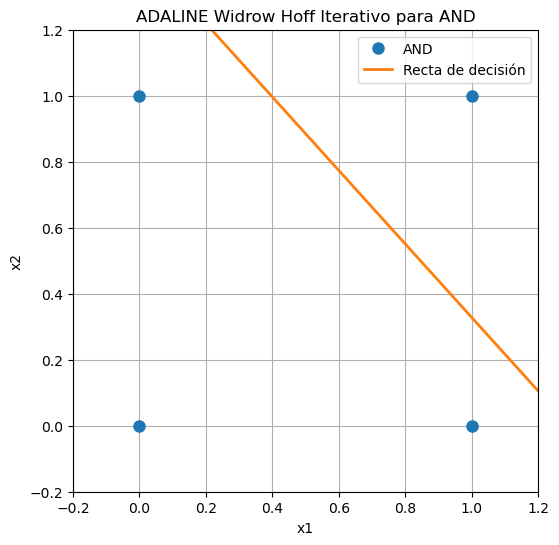

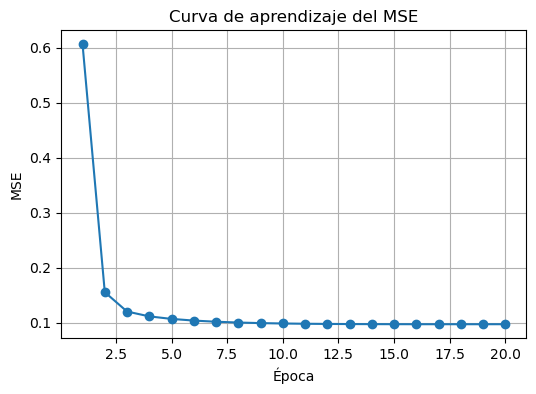

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Datos de AND
P = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]], dtype=float)

t = np.array([0,0,0,1], dtype=int)
Q = len(P)   # Número de patrones

# Inicialización aleatoria de pesos y bias
np.random.seed(0)
w = np.random.rand(2)
b = np.random.rand()

# Parámetros de entrenamiento
alpha = 0.1
epocas = 20

# Lista para guardar el MSE por época
mse_list = []

# Entrenamiento ADALINE Widrow-Hoff iterativo
for epoch in range(epocas):
    suma_error = 0.0
    
    for pq, tq in zip(P, t):
        # salida lineal
        a_q = np.dot(w, pq) + b
        
        # error
        e_q = tq - a_q
        
        # actualización de pesos y bias
        w = w + 2 * alpha * e_q * pq
        b = b + 2 * alpha * e_q
        
        # acumulación del error cuadrático
        suma_error += e_q**2
    
    # MSE de la época
    mse = suma_error / Q
    mse_list.append(mse)

# Salida final de la red
a = np.dot(P, w) + b

# Clasificación final
y_pred = (a > 0.5).astype(int)

# MSE final
mse_final = np.mean((t - a)**2)

# Confusion Matrix
tp = 0
tn = 0
fp = 0
fn = 0

for real, pred in zip(t, y_pred):
    if real == 1 and pred == 1:
        tp += 1
    elif real == 0 and pred == 0:
        tn += 1
    elif real == 0 and pred == 1:
        fp += 1
    elif real == 1 and pred == 0:
        fn += 1

confusion_matrix = np.array([[tn, fp],
                             [fn, tp]])

# Métricas
accuracy = (tp + tn) / (tp + tn + fp + fn)

if (tp + fp) > 0:
    precision = tp / (tp + fp)
else:
    precision = 0.0

if (tp + fn) > 0:
    recall = tp / (tp + fn)
else:
    recall = 0.0

# Imprimir resultados
print("Matriz de datos originales")
print(P)

print("\nVector de etiquetas")
print(t)

print("\nValores iniciales aleatorios ya entrenados")
print(f"\nValor final de b: {b}")
print(f"\nValor final de w: {w}")

print("\nSalida de la red a:")
print(a)

print("\nSALIDA CLASIFICADA y_pred")
print(y_pred)

print("\nMSE final")
print(mse_final)

print("\nCONTEO PARA CONFUSION MATRIX")
print("TN =", tn)
print("FP =", fp)
print("FN =", fn)
print("TP =", tp)

print("\nCONFUSION MATRIX")
print("Filas = reales [0,1]")
print("Columnas = predichas [0,1]")
print(confusion_matrix)

print("\nMÉTRICAS")
print("Accuracy  =", accuracy)
print("Precision =", precision)
print("Recall    =", recall)


# Graficación 
plt.figure(figsize=(6, 6))

plt.plot(P[:, 0], P[:, 1], 'o', markersize=8, label='AND')

# recta de decisión:
# b + w1*x1 + w2*x2 = 0.5
x1_vals = np.linspace(-0.2, 1.2, 100)

if abs(w[1]) > 1e-8:
    x2_vals = (0.5 - b - w[0] * x1_vals) / w[1]
    plt.plot(x1_vals, x2_vals, linewidth=2, label='Recta de decisión')
else:
    x_vertical = (0.5 - b) / w[0]
    plt.axvline(x=x_vertical, linewidth=2, label='Recta de decisión')

plt.xlim(-0.2, 1.2)
plt.ylim(-0.2, 1.2)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("ADALINE Widrow Hoff Iterativo para AND")
plt.grid(True)
plt.legend()
plt.show()

# Gráfica del MSE por época
plt.figure(figsize=(6,4))
plt.plot(range(1, epocas + 1), mse_list, marker='o')
plt.xlabel("Época")
plt.ylabel("MSE")
plt.title("Curva de aprendizaje del MSE")
plt.grid(True)
plt.show()

ADALINE para OR : Widrow-Hoff analítico 

Matriz de datos originales
[[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]

Vector de etiquetas
[0 1 1 1]

Matriz Z
[[0. 0. 1.]
 [0. 1. 1.]
 [1. 0. 1.]
 [1. 1. 1.]]

Matriz R
[[0.5  0.25 0.5 ]
 [0.25 0.5  0.5 ]
 [0.5  0.5  1.  ]]

Vector h
[0.5  0.5  0.75]

Vector solución óptima X
[0.5  0.5  0.25]

Valores de pesos y bias

Valor de b:0.2499999999999999

Valor de w:[0.5 0.5]

Salida de la red a :
[0.25 0.75 0.75 1.25]

SALIDA CLASIFICADA y_pred
[0 1 1 1]

MSE
0.062499999999999986

CONTEO PARA CONFUSION MATRIX
TN = 1
FP = 0
FN = 0
TP = 3

CONFUSION MATRIX
Filas = reales [0,1]
Columnas = predichas [0,1]
[[1 0]
 [0 3]]


MÉTRICAS
Accuracy  = 1.0
Precision = 1.0
Recall    = 1.0


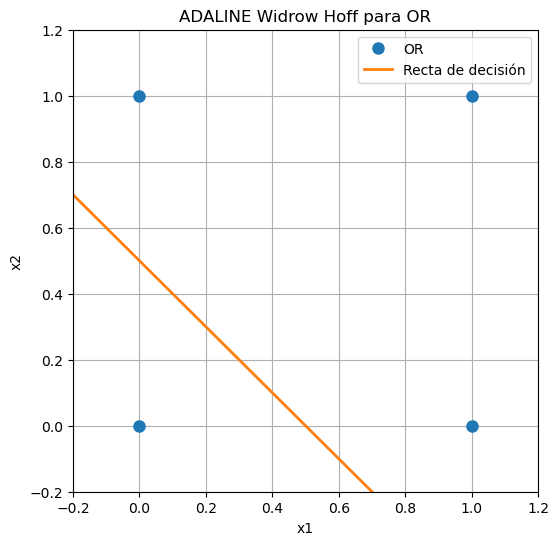

In [23]:
import numpy as np
import matplotlib.pyplot as plt

#Datos de OR
P = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]], dtype=float)

t= np.array([0,1,1,1], dtype=int )
Q= len(P) # Número de patrones

#construcción de Z donde Zq=[p1,p2,1] para cada patrón
Z= np.hstack((P,np.ones((Q, 1))))

#calculo de R y h para cada patrón
#R = (1/Q) * Z^T Z
#h = (1/Q) * Z^T t
R= 1/Q * Z.T @ Z
h= 1/Q * Z.T @ t

#Ahora definimos la solución analitica 
# X= R^-1 h

X_opt= np.linalg.inv(R) @ h

#otra forma de resolver directamente 
#X_solve= np.linalg.solve(R, h)

#separaciónd de pesos y bias
w= X_opt[:2]
b= X_opt[2]

#salida de la red a= Z* X_opt
a= Z @ X_opt

#clasificación final
#de falso/ verdadero convierte a 0 o 1  [false false false true] 
y_pred= (a > 0.5).astype(int)

#calculo de MSE 
mse= np.mean((t-a)**2)

#Confusion Matrix
tp = 0
tn = 0
fp = 0
fn = 0

for real, pred in zip(t, y_pred):
    if real == 1 and pred == 1:
        tp += 1
    elif real == 0 and pred == 0:
        tn += 1
    elif real == 0 and pred == 1:
        fp += 1
    elif real == 1 and pred == 0:
        fn += 1

confusion_matrix = np.array([[tn, fp],
                             [fn, tp]])

#métricas
accuracy = (tp + tn) / (tp + tn + fp + fn)

if (tp + fp) > 0:
    precision = tp / (tp + fp)
else:
    precision = 0.0

if (tp + fn) > 0:
    recall = tp / (tp + fn)
else:
    recall = 0.0

#imprimir resultados

print("Matriz de datos originales")
print(P)

print("\nVector de etiquetas")
print(t)

print ("\nMatriz Z")
print(Z)

print("\nMatriz R")
print(R)

print("\nVector h")
print(h)
print("\nVector solución óptima X")
print(X_opt)

print("\nValores de pesos y bias")
print(f"\nValor de b:{b}")
print(f"\nValor de w:{w}")

print("\nSalida de la red a :")
print(a)


print("\nSALIDA CLASIFICADA y_pred")
print(y_pred)


print("\nMSE")
print(mse)

print("\nCONTEO PARA CONFUSION MATRIX")
print("TN =", tn)
print("FP =", fp)
print("FN =", fn)
print("TP =", tp)

print("\nCONFUSION MATRIX")
print("Filas = reales [0,1]")
print("Columnas = predichas [0,1]")
print(confusion_matrix)

print("\n\nMÉTRICAS")
print("Accuracy  =", accuracy)
print("Precision =", precision)
print("Recall    =", recall)

#Graficación de los puntos y la recta de decisión
plt.figure(figsize=(6, 6))

plt.plot(P[:, 0], P[:, 1], 'o', markersize=8, label='OR')

# recta de decisión:
# b + w1*x1 + w2*x2 = 0.5
x1_vals = np.linspace(-0.2, 1.2, 100)

if abs(w[1]) > 1e-8:
    x2_vals = (0.5 - b - w[0] * x1_vals) / w[1]
    plt.plot(x1_vals, x2_vals, linewidth=2, label='Recta de decisión')
else:
    x_vertical = (0.5 - b) / w[0]
    plt.axvline(x=x_vertical, linewidth=2, label='Recta de decisión')

plt.xlim(-0.2, 1.2)
plt.ylim(-0.2, 1.2)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("ADALINE Widrow Hoff para OR")
plt.grid(True)
plt.legend()
plt.show()


#### ADALINE para OR: Algoritmo iterativo

Matriz de datos originales
[[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]

Vector de etiquetas
[0 1 1 1]

Valores iniciales aleatorios ya entrenados

Valor final de b: 0.3088774925474506

Valor final de w: [0.3769456 0.4401976]

Salida de la red a:
[0.30887749 0.7490751  0.68582309 1.1260207 ]

SALIDA CLASIFICADA y_pred
[0 1 1 1]

MSE final
0.06823923942701024

CONTEO PARA CONFUSION MATRIX
TN = 1
FP = 0
FN = 0
TP = 3

CONFUSION MATRIX
Filas = reales [0,1]
Columnas = predichas [0,1]
[[1 0]
 [0 3]]

MÉTRICAS
Accuracy  = 1.0
Precision = 1.0
Recall    = 1.0


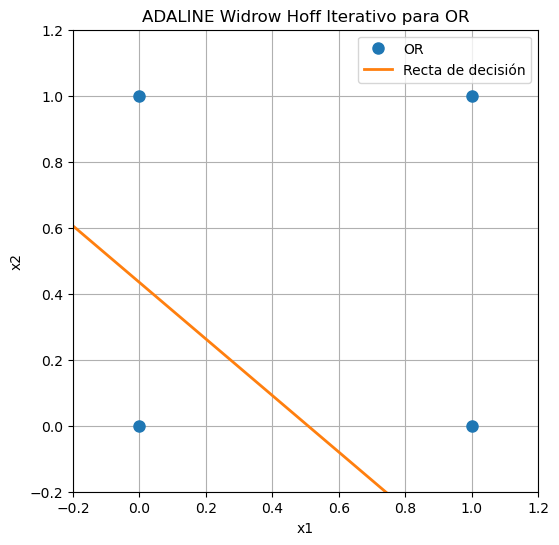

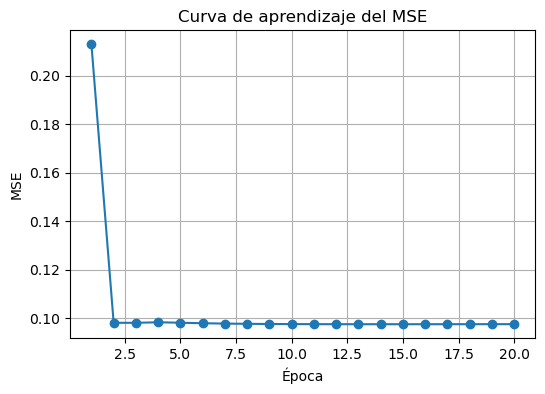

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# Datos de OR
P = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]], dtype=float)

t = np.array([0,1,1,1], dtype=int)
Q = len(P)   # Número de patrones

# Inicialización aleatoria de pesos y bias
np.random.seed(0)
w = np.random.rand(2)
b = np.random.rand()

# Parámetros de entrenamiento
alpha = 0.1
epocas = 20

# Lista para guardar el MSE por época
mse_list = []

# Entrenamiento ADALINE Widrow-Hoff iterativo
for epoch in range(epocas):
    suma_error = 0.0
    
    for pq, tq in zip(P, t):
        # salida lineal
        a_q = np.dot(w, pq) + b
        
        # error
        e_q = tq - a_q
        
        # actualización de pesos y bias
        w = w + 2 * alpha * e_q * pq
        b = b + 2 * alpha * e_q
        
        # acumulación del error cuadrático
        suma_error += e_q**2
    
    # MSE de la época
    mse = suma_error / Q
    mse_list.append(mse)

# Salida final de la red
a = np.dot(P, w) + b

# Clasificación final
y_pred = (a > 0.5).astype(int)

# MSE final
mse_final = np.mean((t - a)**2)

# Confusion Matrix
tp = 0
tn = 0
fp = 0
fn = 0

for real, pred in zip(t, y_pred):
    if real == 1 and pred == 1:
        tp += 1
    elif real == 0 and pred == 0:
        tn += 1
    elif real == 0 and pred == 1:
        fp += 1
    elif real == 1 and pred == 0:
        fn += 1

confusion_matrix = np.array([[tn, fp],
                             [fn, tp]])

# Métricas
accuracy = (tp + tn) / (tp + tn + fp + fn)

if (tp + fp) > 0:
    precision = tp / (tp + fp)
else:
    precision = 0.0

if (tp + fn) > 0:
    recall = tp / (tp + fn)
else:
    recall = 0.0

# Imprimir resultados
print("Matriz de datos originales")
print(P)

print("\nVector de etiquetas")
print(t)

print("\nValores iniciales aleatorios ya entrenados")
print(f"\nValor final de b: {b}")
print(f"\nValor final de w: {w}")

print("\nSalida de la red a:")
print(a)

print("\nSALIDA CLASIFICADA y_pred")
print(y_pred)

print("\nMSE final")
print(mse_final)

print("\nCONTEO PARA CONFUSION MATRIX")
print("TN =", tn)
print("FP =", fp)
print("FN =", fn)
print("TP =", tp)

print("\nCONFUSION MATRIX")
print("Filas = reales [0,1]")
print("Columnas = predichas [0,1]")
print(confusion_matrix)

print("\nMÉTRICAS")
print("Accuracy  =", accuracy)
print("Precision =", precision)
print("Recall    =", recall)


# Graficación 
plt.figure(figsize=(6, 6))

plt.plot(P[:, 0], P[:, 1], 'o', markersize=8, label='OR')

# recta de decisión:
# b + w1*x1 + w2*x2 = 0.5
x1_vals = np.linspace(-0.2, 1.2, 100)

if abs(w[1]) > 1e-8:
    x2_vals = (0.5 - b - w[0] * x1_vals) / w[1]
    plt.plot(x1_vals, x2_vals, linewidth=2, label='Recta de decisión')
else:
    x_vertical = (0.5 - b) / w[0]
    plt.axvline(x=x_vertical, linewidth=2, label='Recta de decisión')

plt.xlim(-0.2, 1.2)
plt.ylim(-0.2, 1.2)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("ADALINE Widrow Hoff Iterativo para OR")
plt.grid(True)
plt.legend()
plt.show()

# Gráfica del MSE por época
plt.figure(figsize=(6,4))
plt.plot(range(1, epocas + 1), mse_list, marker='o')
plt.xlabel("Época")
plt.ylabel("MSE")
plt.title("Curva de aprendizaje del MSE")
plt.grid(True)
plt.show()

#### ADALINE para XOR : Wirdow-Hoff analítico

En el caso XOR, la solución analítica de ADALINE minimiza el error cuadrático, pero debido a que XOR no es linealmente separable, la solución óptima puede obtener  pesos cercanos a cero. En ese caso no existe una frontera lineal de decisión única que pueda graficarse.

Matriz de datos originales
[[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]

Vector de etiquetas
[0 1 1 0]

Matriz Z
[[0. 0. 1.]
 [0. 1. 1.]
 [1. 0. 1.]
 [1. 1. 1.]]

Matriz R
[[0.5  0.25 0.5 ]
 [0.25 0.5  0.5 ]
 [0.5  0.5  1.  ]]

Vector h
[0.25 0.25 0.5 ]

Vector solución óptima X
[0.00000000e+00 2.22044605e-16 5.00000000e-01]

Valores de pesos y bias

Valor de b:0.4999999999999999

Valor de w:[0.00000000e+00 2.22044605e-16]

Salida de la red a :
[0.5 0.5 0.5 0.5]

SALIDA CLASIFICADA y_pred
[0 1 0 1]

MSE
0.25

CONTEO PARA CONFUSION MATRIX
TN = 1
FP = 1
FN = 1
TP = 1

CONFUSION MATRIX
Filas = reales [0,1]
Columnas = predichas [0,1]
[[1 1]
 [1 1]]


MÉTRICAS
Accuracy  = 0.5
Precision = 0.5
Recall    = 0.5


/var/folders/1g/7q9qm0v53fs5smk0p59ptsgw0000gn/T/ipykernel_76840/2745693274.py:139: RuntimeWarning: divide by zero encountered in scalar divide
  x_vertical = (0.5 - b) / w[0]


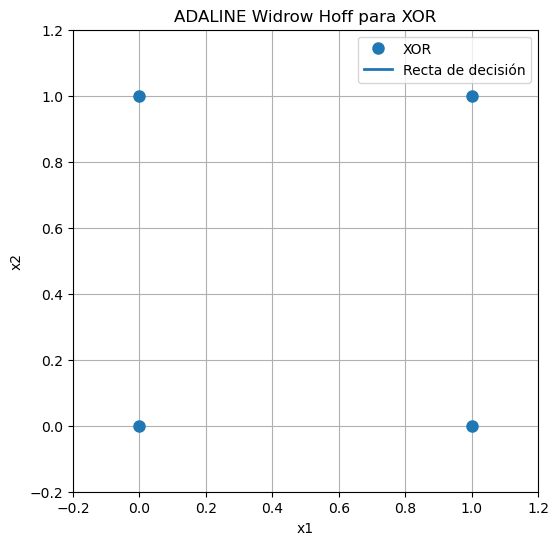

In [10]:
import numpy as np
import matplotlib.pyplot as plt

#Datos de XOR
P = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]], dtype=float)

t= np.array([0,1,1,0], dtype=int )
Q= len(P) # Número de patrones

#construcción de Z donde Zq=[p1,p2,1] para cada patrón
Z= np.hstack((P,np.ones((Q, 1))))

#calculo de R y h para cada patrón
#R = (1/Q) * Z^T Z
#h = (1/Q) * Z^T t
R= 1/Q * Z.T @ Z
h= 1/Q * Z.T @ t

#Ahora definimos la solución analitica 
# X= R^-1 h

X_opt= np.linalg.inv(R) @ h

#otra forma de resolver directamente 
#X_solve= np.linalg.solve(R, h)

#separaciónd de pesos y bias
w= X_opt[:2]
b= X_opt[2]

#salida de la red a= Z* X_opt
a= Z @ X_opt

#clasificación final
#de falso/ verdadero convierte a 0 o 1  [false false false true] 
y_pred= (a > 0.5).astype(int)

#calculo de MSE 
mse= np.mean((t-a)**2)

#Confusion Matrix
tp = 0
tn = 0
fp = 0
fn = 0

for real, pred in zip(t, y_pred):
    if real == 1 and pred == 1:
        tp += 1
    elif real == 0 and pred == 0:
        tn += 1
    elif real == 0 and pred == 1:
        fp += 1
    elif real == 1 and pred == 0:
        fn += 1

confusion_matrix = np.array([[tn, fp],
                             [fn, tp]])

#métricas
accuracy = (tp + tn) / (tp + tn + fp + fn)

if (tp + fp) > 0:
    precision = tp / (tp + fp)
else:
    precision = 0.0

if (tp + fn) > 0:
    recall = tp / (tp + fn)
else:
    recall = 0.0

#imprimir resultados

print("Matriz de datos originales")
print(P)

print("\nVector de etiquetas")
print(t)

print ("\nMatriz Z")
print(Z)

print("\nMatriz R")
print(R)

print("\nVector h")
print(h)
print("\nVector solución óptima X")
print(X_opt)

print("\nValores de pesos y bias")
print(f"\nValor de b:{b}")
print(f"\nValor de w:{w}")

print("\nSalida de la red a :")
print(a)


print("\nSALIDA CLASIFICADA y_pred")
print(y_pred)


print("\nMSE")
print(mse)

print("\nCONTEO PARA CONFUSION MATRIX")
print("TN =", tn)
print("FP =", fp)
print("FN =", fn)
print("TP =", tp)

print("\nCONFUSION MATRIX")
print("Filas = reales [0,1]")
print("Columnas = predichas [0,1]")
print(confusion_matrix)

print("\n\nMÉTRICAS")
print("Accuracy  =", accuracy)
print("Precision =", precision)
print("Recall    =", recall)

#Graficación de los puntos y la recta de decisión
plt.figure(figsize=(6, 6))

plt.plot(P[:, 0], P[:, 1], 'o', markersize=8, label='XOR')

# recta de decisión:
# b + w1*x1 + w2*x2 = 0.5
x1_vals = np.linspace(-0.2, 1.2, 100)

if abs(w[1]) > 1e-8:
    x2_vals = (0.5 - b - w[0] * x1_vals) / w[1]
    plt.plot(x1_vals, x2_vals, linewidth=2, label='Recta de decisión')
else:
    x_vertical = (0.5 - b) / w[0]
    plt.axvline(x=x_vertical, linewidth=2, label='Recta de decisión')

plt.xlim(-0.2, 1.2)
plt.ylim(-0.2, 1.2)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("ADALINE Widrow Hoff para XOR")
plt.grid(True)
plt.legend()
plt.show()




#### ADALINE para XOR : Algoritmo iterativo

Aunque el MSE disminuye en el entrenamiento de ADALINE para XOR, esto no implica una correcta clasificación, ya que el algoritmo minimiza el error cuadrático medio y no el error de clasificación. Debido a que XOR no es linealmente separable, el modelo  aproxima las salidas, pero no logra separarlas correctamente.

Matriz de datos originales
[[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]

Vector de etiquetas
[0 1 1 0]

Valores iniciales aleatorios ya entrenados

Valor final de b: 0.5887385417383052

Valor final de w: [-0.22803482 -0.10064973]

Salida de la red a:
[0.58873854 0.48808881 0.36070372 0.26005399]

SALIDA CLASIFICADA y_pred
[1 0 0 0]

MSE final
0.2712484862392491

CONTEO PARA CONFUSION MATRIX
TN = 1
FP = 1
FN = 2
TP = 0

CONFUSION MATRIX
Filas = reales [0,1]
Columnas = predichas [0,1]
[[1 1]
 [2 0]]

MÉTRICAS
Accuracy  = 0.25
Precision = 0.0
Recall    = 0.0


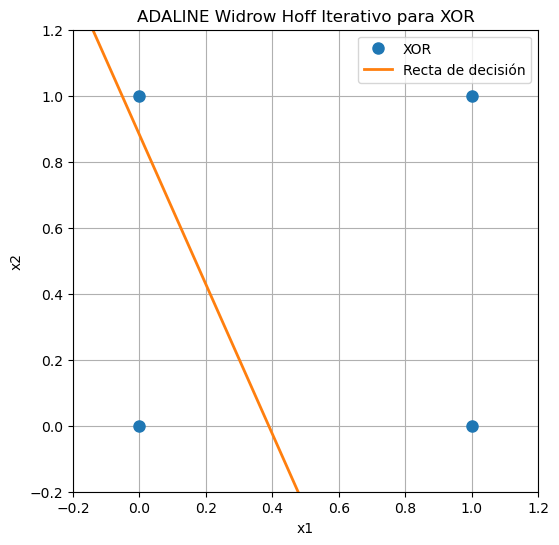

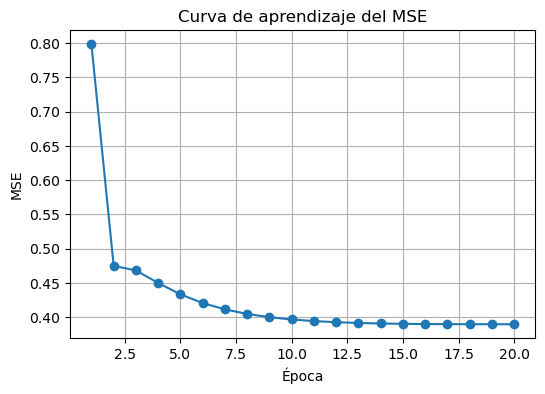

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Datos de XOR
P = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]], dtype=float)

t = np.array([0,1,1,0], dtype=int)
Q = len(P)   # Número de patrones

# Inicialización aleatoria de pesos y bias
np.random.seed(0)
w = np.random.rand(2)
b = np.random.rand()

# Parámetros de entrenamiento
alpha = 0.1
epocas = 20

# Lista para guardar el MSE por época
mse_list = []

# Entrenamiento ADALINE Widrow-Hoff iterativo
for epoch in range(epocas):
    suma_error = 0.0
    
    for pq, tq in zip(P, t):
        # salida lineal
        a_q = np.dot(w, pq) + b
        
        # error
        e_q = tq - a_q
        
        # actualización de pesos y bias
        w = w + 2 * alpha * e_q * pq
        b = b + 2 * alpha * e_q
        
        # acumulación del error cuadrático
        suma_error += e_q**2
    
    # MSE de la época
    mse = suma_error / Q
    mse_list.append(mse)

# Salida final de la red
a = np.dot(P, w) + b

# Clasificación final
y_pred = (a > 0.5).astype(int)

# MSE final
mse_final = np.mean((t - a)**2)

# Confusion Matrix
tp = 0
tn = 0
fp = 0
fn = 0

for real, pred in zip(t, y_pred):
    if real == 1 and pred == 1:
        tp += 1
    elif real == 0 and pred == 0:
        tn += 1
    elif real == 0 and pred == 1:
        fp += 1
    elif real == 1 and pred == 0:
        fn += 1

confusion_matrix = np.array([[tn, fp],
                             [fn, tp]])

# Métricas
accuracy = (tp + tn) / (tp + tn + fp + fn)

if (tp + fp) > 0:
    precision = tp / (tp + fp)
else:
    precision = 0.0

if (tp + fn) > 0:
    recall = tp / (tp + fn)
else:
    recall = 0.0

# Imprimir resultados
print("Matriz de datos originales")
print(P)

print("\nVector de etiquetas")
print(t)

print("\nValores iniciales aleatorios ya entrenados")
print(f"\nValor final de b: {b}")
print(f"\nValor final de w: {w}")

print("\nSalida de la red a:")
print(a)

print("\nSALIDA CLASIFICADA y_pred")
print(y_pred)

print("\nMSE final")
print(mse_final)

print("\nCONTEO PARA CONFUSION MATRIX")
print("TN =", tn)
print("FP =", fp)
print("FN =", fn)
print("TP =", tp)

print("\nCONFUSION MATRIX")
print("Filas = reales [0,1]")
print("Columnas = predichas [0,1]")
print(confusion_matrix)

print("\nMÉTRICAS")
print("Accuracy  =", accuracy)
print("Precision =", precision)
print("Recall    =", recall)


# Graficación 
plt.figure(figsize=(6, 6))

plt.plot(P[:, 0], P[:, 1], 'o', markersize=8, label='XOR')

# recta de decisión:
# b + w1*x1 + w2*x2 = 0.5
x1_vals = np.linspace(-0.2, 1.2, 100)

if abs(w[1]) > 1e-8:
    x2_vals = (0.5 - b - w[0] * x1_vals) / w[1]
    plt.plot(x1_vals, x2_vals, linewidth=2, label='Recta de decisión')
else:
    x_vertical = (0.5 - b) / w[0]
    plt.axvline(x=x_vertical, linewidth=2, label='Recta de decisión')

plt.xlim(-0.2, 1.2)
plt.ylim(-0.2, 1.2)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("ADALINE Widrow Hoff Iterativo para XOR")
plt.grid(True)
plt.legend()
plt.show()

# Gráfica del MSE por época
plt.figure(figsize=(6,4))
plt.plot(range(1, epocas + 1), mse_list, marker='o')
plt.xlabel("Época")
plt.ylabel("MSE")
plt.title("Curva de aprendizaje del MSE")
plt.grid(True)
plt.show()

### ADALINE para fitting de una recta : Widrow-Hoff analítico

Matriz de datos originales P
[[ 1.]
 [ 2.]
 [ 3.]
 [ 4.]
 [ 5.]
 [ 6.]
 [ 7.]
 [ 8.]
 [ 9.]
 [10.]
 [11.]
 [12.]
 [13.]
 [14.]
 [15.]]

Vector de tags t
[ 3.1  4.9  7.2  8.8 11.5 12.7 15.3 16.9 19.8 21.2 23.5 24.7 27.6 28.9
 31.4]

Matriz Z
[[ 1.  1.]
 [ 2.  1.]
 [ 3.  1.]
 [ 4.  1.]
 [ 5.  1.]
 [ 6.  1.]
 [ 7.  1.]
 [ 8.  1.]
 [ 9.  1.]
 [10.  1.]
 [11.  1.]
 [12.  1.]
 [13.  1.]
 [14.  1.]
 [15.  1.]]

Matriz R
[[82.66666667  8.        ]
 [ 8.          1.        ]]

Vector h
[175.01333333  17.16666667]

Vector solución óptima X
[2.01857143 1.01809524]

Valor de w
2.018571428571428

Valor de b
1.0180952380952402

Salida de la red a
[ 3.03666667  5.0552381   7.07380952  9.09238095 11.11095238 13.12952381
 15.14809524 17.16666667 19.1852381  21.20380952 23.22238095 25.24095238
 27.25952381 29.27809524 31.29666667]

MSE
0.1051174603174608


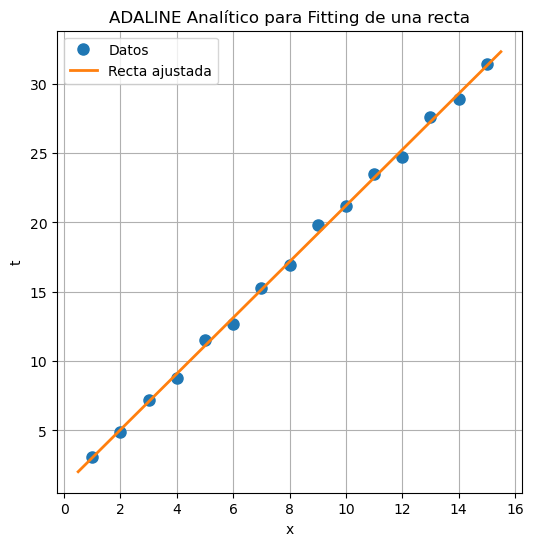

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Datos de entrada eje x
P = np.array([[1],
              [2],
              [3],
              [4],
              [5],
              [6],
              [7],
              [8],
              [9],
              [10],
              [11],
              [12],
              [13],
              [14],
              [15]
              ], dtype=float)

# Valores del objetivo o "y" para cada patrón
t = np.array([3.1,
              4.9,
              7.2,
              8.8,
              11.5,
              12.7,
              15.3,
              16.9,
              19.8,
              21.2,
              23.5,
              24.7,
              27.6,
              28.9,
              31.4], dtype=float)

Q = len(P)   # número de patrones

# Construcción de Z donde Zq = [p1, 1] para cada patrón
Z = np.hstack((P, np.ones((Q, 1))))

# Cálculo de R y h
# R = (1/Q) * Z^T Z
# h = (1/Q) * Z^T t
R = (1 / Q) * Z.T @ Z
h = (1 / Q) * Z.T @ t

# Solución analítica
# X = R^-1 h
X_opt = np.linalg.inv(R) @ h

# Separación de peso y bias
w = X_opt[0]
b = X_opt[1]

# Salida de la red
a = Z @ X_opt

# Cálculo del MSE
mse = np.mean((t - a) ** 2)

# Imprimir resultados
print("Matriz de datos originales P")
print(P)

print("\nVector de tags t")
print(t)

print("\nMatriz Z")
print(Z)

print("\nMatriz R")
print(R)

print("\nVector h")
print(h)

print("\nVector solución óptima X")
print(X_opt)

print("\nValor de w")
print(w)

print("\nValor de b")
print(b)

print("\nSalida de la red a")
print(a)

print("\nMSE")
print(mse)

# Graficación de los puntos y la recta ajustada
plt.figure(figsize=(6, 6))

plt.plot(P[:, 0], t, 'o', markersize=8, label='Datos')

x_vals = np.linspace(np.min(P) - 0.5, np.max(P) + 0.5, 100)
y_vals = w * x_vals + b

plt.plot(x_vals, y_vals, linewidth=2, label='Recta ajustada')

plt.xlabel("x")
plt.ylabel("t")
plt.title("ADALINE Analítico para Fitting de una recta")
plt.grid(True)
plt.legend()
plt.show()

### ADALINE para fitting de una recta: Algoritmo iterativo

Matriz de datos originales P
[[ 1.]
 [ 2.]
 [ 3.]
 [ 4.]
 [ 5.]
 [ 6.]
 [ 7.]
 [ 8.]
 [ 9.]
 [10.]
 [11.]
 [12.]
 [13.]
 [14.]
 [15.]]

Vector de etiquetas t
[ 3.1  4.9  7.2  8.8 11.5 12.7 15.3 16.9 19.8 21.2 23.5 24.7 27.6 28.9
 31.4]

Valor final de w
[2.02388168]

Valor final de b
0.933475067949192

Salida final de la red a
[ 2.95735675  4.98123842  7.0051201   9.02900178 11.05288345 13.07676513
 15.10064681 17.12452849 19.14841016 21.17229184 23.19617352 25.2200552
 27.24393687 29.26781855 31.29170023]

MSE final
0.10741946301962955


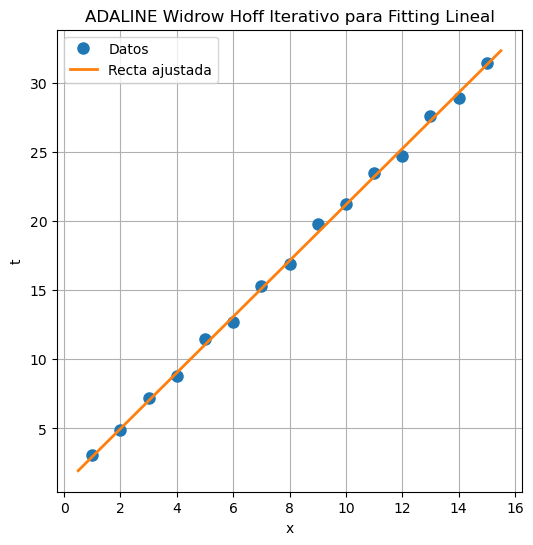

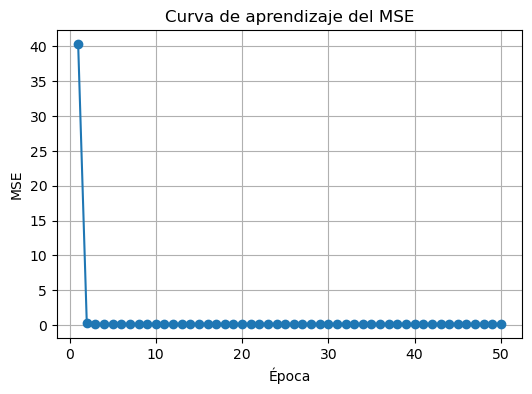

In [20]:
#ADALINE Iterativo para Fitting de una recta

import numpy as np
import matplotlib.pyplot as plt

# Datos de entrada
P = np.array([[1],
              [2],
              [3],
              [4],
              [5],
              [6],
              [7],
              [8],
              [9],
              [10],
              [11],
              [12],
              [13],
              [14],
              [15]], dtype=float)

# Valores objetivo
t = np.array([3.1,
              4.9,
              7.2,
              8.8,
              11.5,
              12.7,
              15.3,
              16.9,
              19.8,
              21.2,
              23.5,
              24.7,
              27.6,
              28.9,
              31.4], dtype=float)

Q = len(P)   # Número de patrones

# Inicialización aleatoria de peso y bias
np.random.seed(0)
w = np.random.rand(1)
b = np.random.rand()

# Parámetros de entrenamiento
alpha = 0.001
epocas = 50

# Lista para guardar el MSE por época
mse_list = []

# Entrenamiento ADALINE Widrow-Hoff iterativo
for epoch in range(epocas):
    suma_error = 0.0

    for pq, tq in zip(P, t):
        # salida lineal
        a_q = np.dot(w, pq) + b

        # error
        e_q = tq - a_q

        # actualización de peso y bias
        w = w + 2 * alpha * e_q * pq
        b = b + 2 * alpha * e_q

        # acumulación del error cuadrático
        suma_error += e_q**2

    # MSE de la época
    mse = suma_error / Q
    mse_list.append(mse)

# Salida final de la red
a = np.dot(P, w) + b

# MSE final
mse_final = np.mean((t - a.flatten())**2)

# Imprimir resultados
print("Matriz de datos originales P")
print(P)

print("\nVector de etiquetas t")
print(t)

print("\nValor final de w")
print(w)

print("\nValor final de b")
print(b)

print("\nSalida final de la red a")
print(a)

print("\nMSE final")
print(mse_final)


# Graficación de los puntos y la recta ajustada
plt.figure(figsize=(6, 6))

plt.plot(P[:, 0], t, 'o', markersize=8, label='Datos')

x_vals = np.linspace(np.min(P) - 0.5, np.max(P) + 0.5, 100)
y_vals = w[0] * x_vals + b

plt.plot(x_vals, y_vals, linewidth=2, label='Recta ajustada')

plt.xlabel("x")
plt.ylabel("t")
plt.title("ADALINE Widrow Hoff Iterativo para Fitting Lineal")
plt.grid(True)
plt.legend()
plt.show()

# Gráfica del MSE por época
plt.figure(figsize=(6,4))
plt.plot(range(1, epocas + 1), mse_list, marker='o')
plt.xlabel("Época")
plt.ylabel("MSE")
plt.title("Curva de aprendizaje del MSE")
plt.grid(True)
plt.show()

